In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

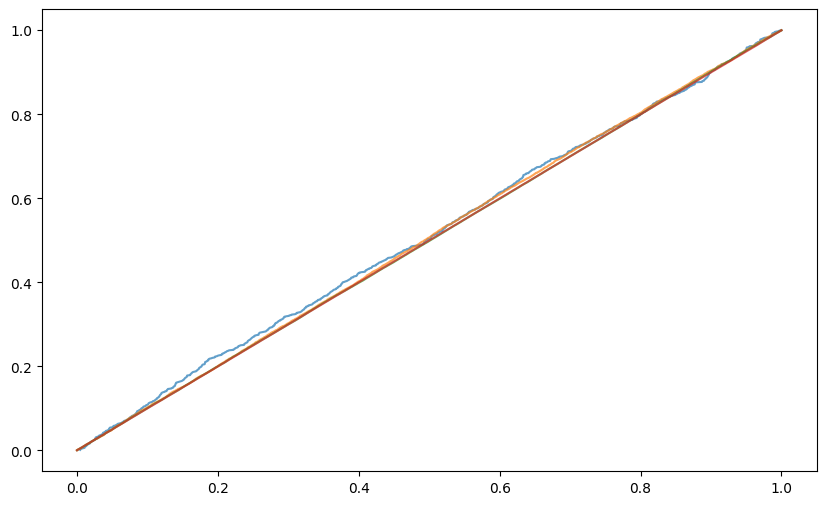

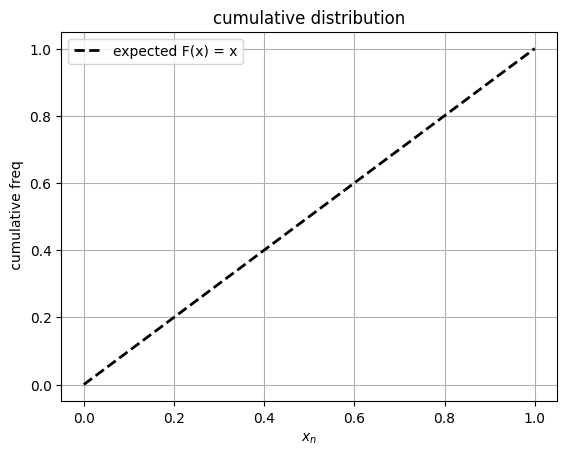

In [31]:
np.random.seed(42)
Ns = [10**3, 10**4, 10**5, 10**6]      

# 1A
plt.figure(figsize=(10, 6))
for N in Ns:
  x = np.random.rand(N)
  x = np.sort(x)
  y = np.arange(1, N + 1) / N
  plt.plot(x, y, label=f"N = {N}", alpha=0.7)
plt.show()


# for expected cum. distribution for uniform

x_exp = np.linspace(0, 1, 100)
plt.plot(x_exp, x_exp, "k--", linewidth=2, label="expected F(x) = x")
plt.xlabel("$x_n$")
plt.ylabel(" cumulative freq")
plt.title("cumulative distribution")
plt.legend()
plt.grid(True)
plt.show()

In [39]:
# 1b
print(
    f"{'N':<10} | {'mean':<10} | {'stdev':<10} | {'skewness':<10} |"
    f" {'kurtosis':<10}"
)

print(
    f"{'expected':<10} | {0.5:<10.4f} | {1/np.sqrt(12):<10.4f} | {0.0:<10.4f} |"
    f" {-1.2:<10.4f}"
)


for N in Ns:
  x = np.random.rand(N)
  mean_v = np.mean(x)
  std_v = np.std(x, ddof=1)
  
  # Using stats.skew and stats.kurtosis prevents variable name collisions
  skew_v = stats.skew(x)
  kurt_v = stats.kurtosis(x, fisher=True)

  print(
      f"{N:<10} | {mean_v:<10.4f} | {std_v:<10.4f} | {skew_v:<10.4f} |"
      f" {kurt_v:<10.4f}"
  )

N          | mean       | stdev      | skewness   | kurtosis  
expected   | 0.5000     | 0.2887     | 0.0000     | -1.2000   
1000       | 0.5060     | 0.2864     | -0.0344    | -1.1727   
10000      | 0.4960     | 0.2887     | 0.0259     | -1.2026   
100000     | 0.5000     | 0.2889     | -0.0048    | -1.1972   
1000000    | 0.5003     | 0.2887     | -0.0016    | -1.2001   


In [40]:

# 1c
print(f"{'N':<10} | {'mean of diff':<15} | {'stdev of diff':<15}")
# mean_exp = 0, stdev_exp = sqrt(1/6) = 0.4082
print(f"{'expected':<10} | {0.0:<15.4f} | {np.sqrt(1/6):<15.4f}")

for N in Ns:
  x = np.random.rand(N)
  diffs = np.diff(x)
  print(
      f"{N:<10} | {np.mean(diffs):<15.4f} | {np.std(diffs, ddof=1):<15.4f}"
  )


N          | mean of diff    | stdev of diff  
expected   | 0.0000          | 0.4082         
1000       | 0.0003          | 0.4091         
10000      | 0.0000          | 0.4116         
100000     | -0.0000         | 0.4100         
1000000    | -0.0000         | 0.4085         


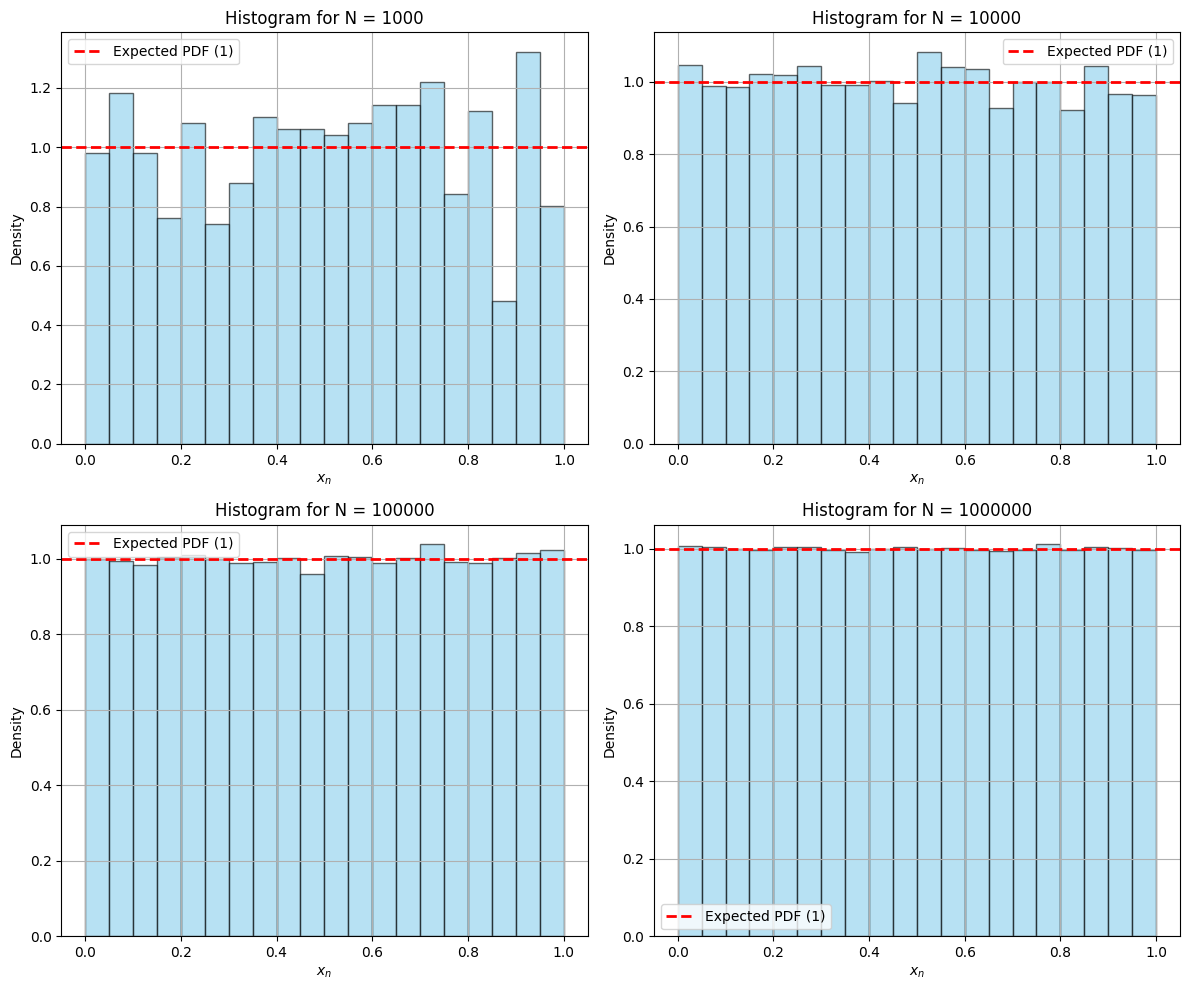

In [42]:
# 1d
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, N in enumerate(Ns):
  x = np.random.rand(N)
  axes[i].hist(
      x,
      bins=20,
      density=True,
      alpha=0.6,
      color="skyblue",
      edgecolor="black",
  )
  # expected uniform probability density function is 1 over the interval [0,1] 
  #  height = 1
  axes[i].axhline(
      1.0, color="red", linestyle="dashed", linewidth=2, label="Expected PDF (1)"
  )
  axes[i].set_title(f"Histogram for N = {N}")
  axes[i].set_xlabel("$x_n$")
  axes[i].set_ylabel("Density")
  axes[i].legend()
  axes[i].grid(True)

plt.tight_layout()
plt.show()

Ns = [10**3, 10**4, 10**5, 10**6]

# inverse transform sampling 
# A = 1 for the distribution f(y) = A(1 - |y|) on (-1, 1)
def generate_triangular_dist(N):
  u = np.random.rand(N)
  y = np.empty_like(u)

  # lower half
  mask = u <= 0.5
  y[mask] = -1.0 + np.sqrt(2.0 * u[mask])

  # upper half
  y[~mask] = 1.0 - np.sqrt(2.0 * (1.0 - u[~mask]))
  return y
# 2
print(
    f"{'N':<10} | {'mean':<10} | {'stdev':<10} | {'skewness':<10} |"
    f" {'kurtosis':<10}"
)
print(
    f"{'expected':<10} | {0.0:<10.4f} | {np.sqrt(1/6):<10.4f} | {0.0:<10.4f} |"
    f" {-0.6:<10.4f}"
)
for N in Ns:
  y = generate_triangular_dist(N)
  mean_val = np.mean(y)
  std_val = np.std(y, ddof=1)
  skew_val = stats.skew(y)
  kurt_val = stats.kurtosis(y, fisher=True)  # Excess kurtosis

  print(
      f"{N:<10} | {mean_val:<10.4f} | {std_val:<10.4f} | {skew_val:<10.4f} |"
      f" {kurt_val:<10.4f}"
  )

mean_exp: 0.0000 | sample mean: 0.0021
stdev_exp: 1.0000 | sample stdev: 0.9994


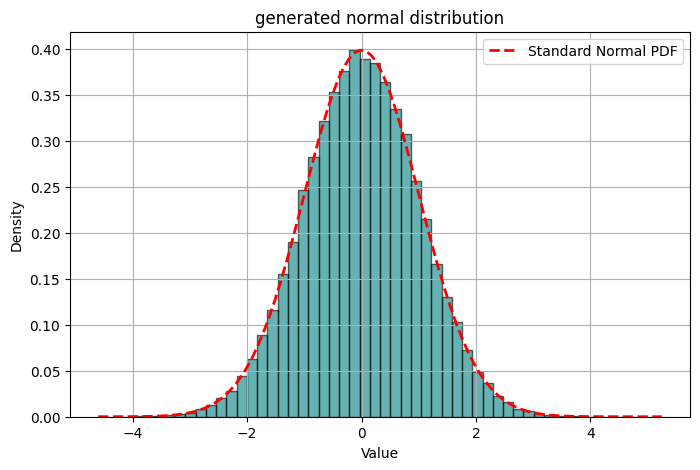

In [43]:

np.random.seed(42)


def generate_gaussian(N):
  u1 = np.random.rand(N)
  u2 = np.random.rand(N)

  # box-nuller transform 
  z0 = np.sqrt(-2.0 * np.log(u1)) * np.cos(2.0 * np.pi * u2)
  return z0

N_test = 10**5
normal_samples = generate_gaussian(N_test)

# 3

print(f"mean_exp: 0.0000 | sample mean: {np.mean(normal_samples):.4f}")
print(
    f"stdev_exp: 1.0000 | sample stdev:"
    f" {np.std(normal_samples, ddof=1):.4f}"
)

plt.figure(figsize=(8, 5))
count, bins, ignored = plt.hist(
    normal_samples, bins=50, density=True, alpha=0.6, color="teal", edgecolor="black"
)

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x**2)
plt.plot(x, p, "r--", linewidth=2, label="Standard Normal PDF")

plt.title("generated normal distribution")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()
